In [2]:
import os
from pathlib import Path
import pandas as pd
import pysam
from icecream import ic
import numpy as np
from tqdm import tqdm
from scipy.optimize import minimize

import sys
from pathlib import Path
# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))
from Plotter import Plotter

from ChromatinFibers import (
    convert_to_footprints,
    fetch_chromosome_sequence,
    ChromatinFiber,
    compute_vanderlick,
)

from Plotter import Plotter, plot_sequence, plot_footprints
from pycorrelate import pcorrelate

plot = Plotter()
FILEOUT = rf"figures/SimulateYeastFibers.jpg"

# Create the directory if it doesn't exist
output_dir = os.path.dirname(FILEOUT)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

In [3]:
filename = "occupancy_locus(chrII:273000-283000)"
occupancy = np.load(f"methylation_occupancy/{filename}.npy")
def extract_locus(locus_txt):
    locus_txt = locus_txt.replace(',', '')
    parts = locus_txt.split(':')
    chrom = parts[0]
    start, end = map(int, parts[1].split('-'))
    return (chrom, start, end)

locus = extract_locus(filename.lstrip("occupancy_locus(").rstrip(")"))
chrom, start, end = locus

In [4]:
chrom_number = chrom.lstrip("chr")

chromosome = fetch_chromosome_sequence(r".genomes/sacCer3/sacCer3.fa", chromosome=chrom_number)
length = end-start + 2000
#locus_start = np.random.randint(0, len(chromosome) - length)
locus_start = start - 1000
locus_end = locus_start + length
#locus_sequence = chromosome[-10001 : -1]
locus_sequence = chromosome[locus_start : locus_end]
fiber = ChromatinFiber(sequence=locus_sequence,start = locus_start)
fiber.fetch_orfs_by_range(start=locus_start, end=locus_end, chromosome=chrom_number)

Selected chromosome: .genomes/sacCer3, chrII  len=813184


In [5]:
import numpy as np
from scipy.optimize import minimize, differential_evolution

def model_func(fiber, period, amplitude, chemical_potential):
    fiber.calc_energy_landscape(
        octamer=True,
        period=period,
        amplitude=amplitude,
        chemical_potential=chemical_potential,
    )
    return fiber.occupancy[1000:-1000]

def lsq_fit(fiber, occupancy, model_func, bounds, x0=None, use_de=True):
    y_data = np.asarray(occupancy)

    def cost(params):
        y_pred = model_func(fiber, *params)
        return np.sum((y_pred - y_data) ** 2)

    if use_de:
        # Global search — no x0 needed, just bounds
        result = differential_evolution(
            cost,
            bounds=bounds,
            strategy='best1bin',
            maxiter=1000,
            tol=1e-7,
            seed=0,
            polish=True,   # auto-runs L-BFGS-B at the end
        )
    else:
        # Local search — needs x0
        if x0 is None:
            x0 = [(lo + hi) / 2 for lo, hi in bounds]
        result = minimize(
            cost,
            x0=x0,
            method='L-BFGS-B',
            bounds=bounds,
            options={'ftol': 1e-5},
        )
    return result.x


bounds = [
    (8, 12),   # period
    (0.001, 0.249),  # amplitude
    (0, 20),       # chemical_potential
]

In [6]:
segment_length = 400
segments = (end-start) // segment_length
seg_model_len = segment_length + 2000
var_dic = {'amplitude': np.zeros(segments), 'period': np.zeros(segments), 'chemical_potential': np.zeros(segments)}


for k in tqdm(range(segments)):
    seg_start = locus_start + (k * segment_length)
    seg_end = seg_start + seg_model_len
    if seg_end > locus_end:
        seg_end = locus_end
    seg_sequence = chromosome[seg_start:seg_end]
    seg_fiber = ChromatinFiber(sequence=seg_sequence, start=seg_start)
    period_lsq, amplitude_lsq, chemical_potential_lsq = lsq_fit(seg_fiber, occupancy[k*segment_length:(k+1)*segment_length], model_func, bounds, x0=None, use_de=True)
    var_dic['amplitude'][k] = amplitude_lsq
    var_dic['period'][k] = period_lsq
    var_dic['chemical_potential'][k] = chemical_potential_lsq


100%|██████████| 25/25 [13:05<00:00, 31.43s/it]


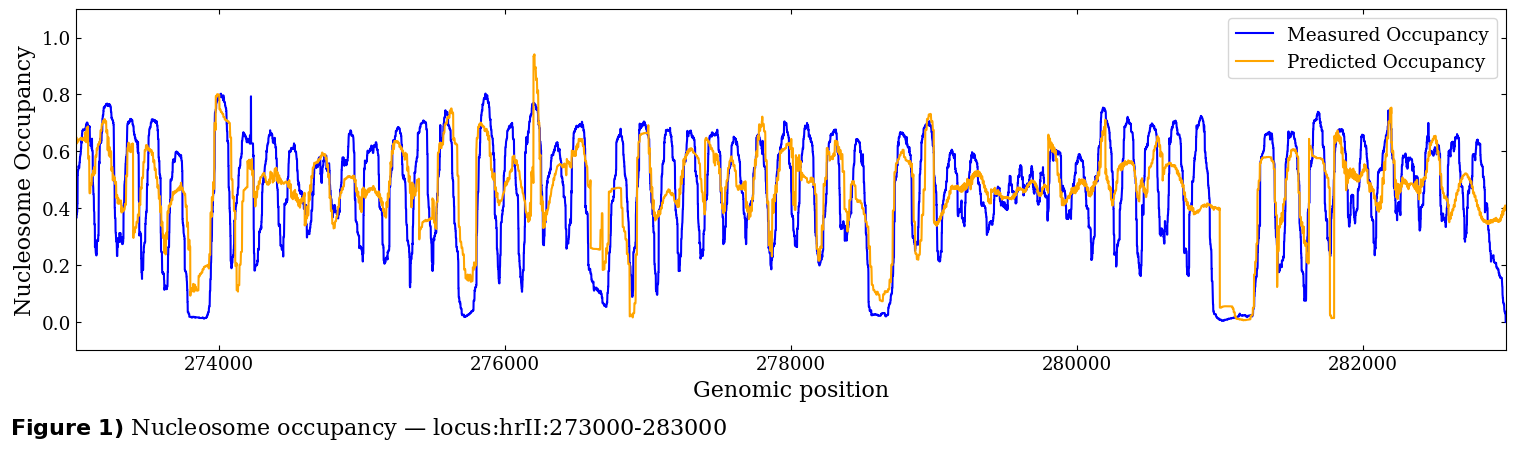

In [7]:
x_coords = np.arange(start, end)
distribution = []

for k in range(segments):
    seg_start = locus_start + (k * segment_length)
    seg_end = seg_start + seg_model_len
    if seg_end > locus_end:
        seg_end = locus_end
    seg_sequence = chromosome[seg_start:seg_end]
    seg_fiber = ChromatinFiber(sequence=seg_sequence, start=seg_start)
    seg_fiber.calc_energy_landscape(
        octamer=True,
        period=var_dic['period'][k],
        amplitude=var_dic['amplitude'][k],
        chemical_potential=var_dic['chemical_potential'][k],
    )
    distribution.extend(seg_fiber.occupancy[1000:-1000])

plotter = Plotter(fig_size=(15, 4))
plotter.new(ncols=1, nrows=1)
ax = plotter.axes
ax.plot(x_coords, occupancy, color='blue', label='Measured Occupancy')
ax.plot(x_coords, distribution, color='orange', label='Predicted Occupancy')
ax.set_ylim(-0.1, 1.1)
ax.set_xlim(start, end)
ax.set_xlabel("Genomic position")
ax.set_ylabel("Nucleosome Occupancy")
ax.legend()
plotter.caption(f"Nucleosome occupancy — locus:{chrom}:{start}-{end}")

In [8]:
print(max(var_dic['period']), min(var_dic['period']))
print(max(var_dic['amplitude']), min(var_dic['amplitude']))
print(max(var_dic['chemical_potential']), min(var_dic['chemical_potential']))

11.57312392847127 8.037633475074221
0.1154879995018422 0.021612235376513782
20.0 5.00296213929998


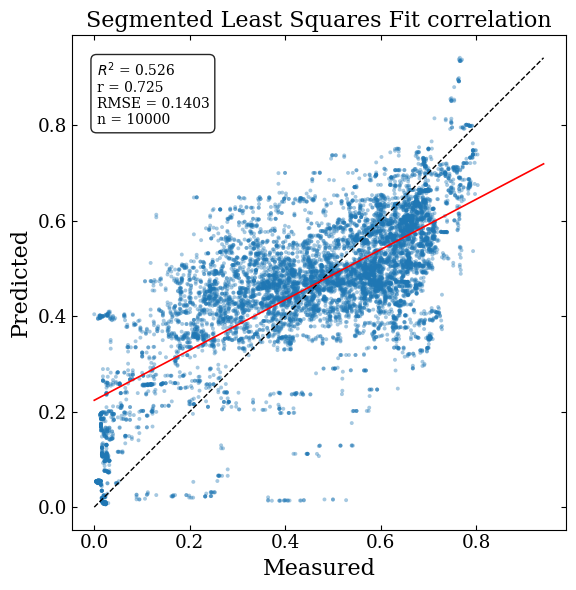

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_correlation(measured, predicted, ax=None, title=None):
    """
    Scatter plot of predicted vs measured values with R² and Pearson r.

    Parameters
    ----------
    measured : array-like
        Observed/experimental occupancy.
    predicted : array-like
        Model output (e.g. from model_func with fitted parameters).
    ax : matplotlib Axes, optional
        Existing axis to draw into. If None, a new figure is created.
    title : str, optional
    """
    measured = np.asarray(measured).ravel()
    predicted = np.asarray(predicted).ravel()

    if measured.shape != predicted.shape:
        raise ValueError(
            f"Shape mismatch: measured {measured.shape} vs predicted {predicted.shape}"
        )

    # Statistics
    r, p_value = pearsonr(measured, predicted)
    r_squared = r ** 2
    rmse = np.sqrt(np.mean((predicted - measured) ** 2))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Scatter
    ax.scatter(measured, predicted, s=8, alpha=0.4, edgecolor='none')

    # y = x reference line
    lo = min(measured.min(), predicted.min())
    hi = max(measured.max(), predicted.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')

    # Linear fit line
    slope, intercept = np.polyfit(measured, predicted, 1)
    xs = np.array([lo, hi])
    ax.plot(xs, slope * xs + intercept, 'r-', lw=1.2,
            label=f'fit: y = {slope:.2f}x + {intercept:.2f}')

    ax.set_xlabel('Measured')
    ax.set_ylabel('Predicted')
    ax.set_title(title or 'Segmented Least Squares Fit correlation')
    ax.set_aspect('equal', adjustable='box')

    # Annotation box with stats
    stats_text = (
        f'$R^2$ = {r_squared:.3f}\n'
        f'r = {r:.3f}\n'
        f'RMSE = {rmse:.4f}\n'
        f'n = {len(measured)}'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    plt.tight_layout()
    return measured, predicted, slope, intercept, r, r_squared, ax

m, p, s, i, r, r_squared, a = plot_correlation(occupancy, distribution)

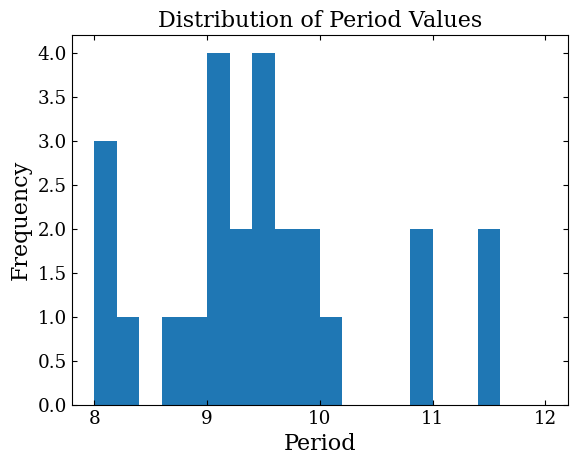

In [10]:
plt.hist(var_dic['period'], bins=20, range=(8, 12))
plt.xlabel("Period")
plt.ylabel("Frequency")
plt.title("Distribution of Period Values")
plt.show()

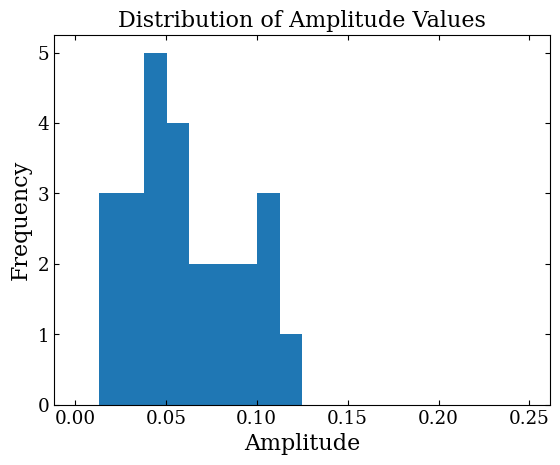

In [11]:
plt.hist(var_dic['amplitude'], bins=20, range=(0.001, 0.249))
plt.xlabel("Amplitude")
plt.ylabel("Frequency")
plt.title("Distribution of Amplitude Values")
plt.show()

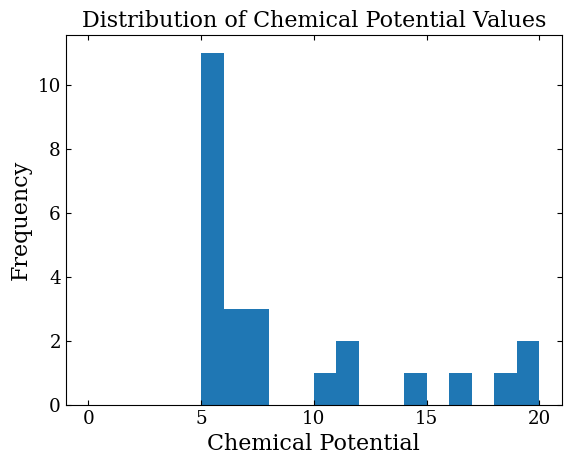

In [12]:
plt.hist(var_dic['chemical_potential'], bins=20, range=(0, 20))
plt.xlabel("Chemical Potential")
plt.ylabel("Frequency")
plt.title("Distribution of Chemical Potential Values")
plt.show()

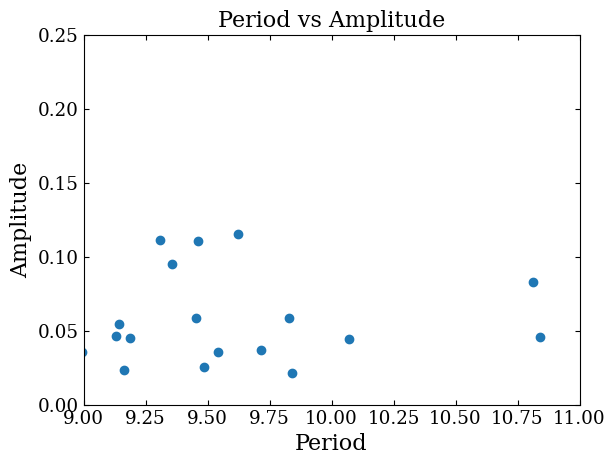

In [13]:
plt.scatter(var_dic['period'], var_dic['amplitude'])
plt.ylim(0, 0.25)
plt.xlim(9, 11)
plt.xlabel("Period")
plt.ylabel("Amplitude")
plt.title("Period vs Amplitude")
plt.show()

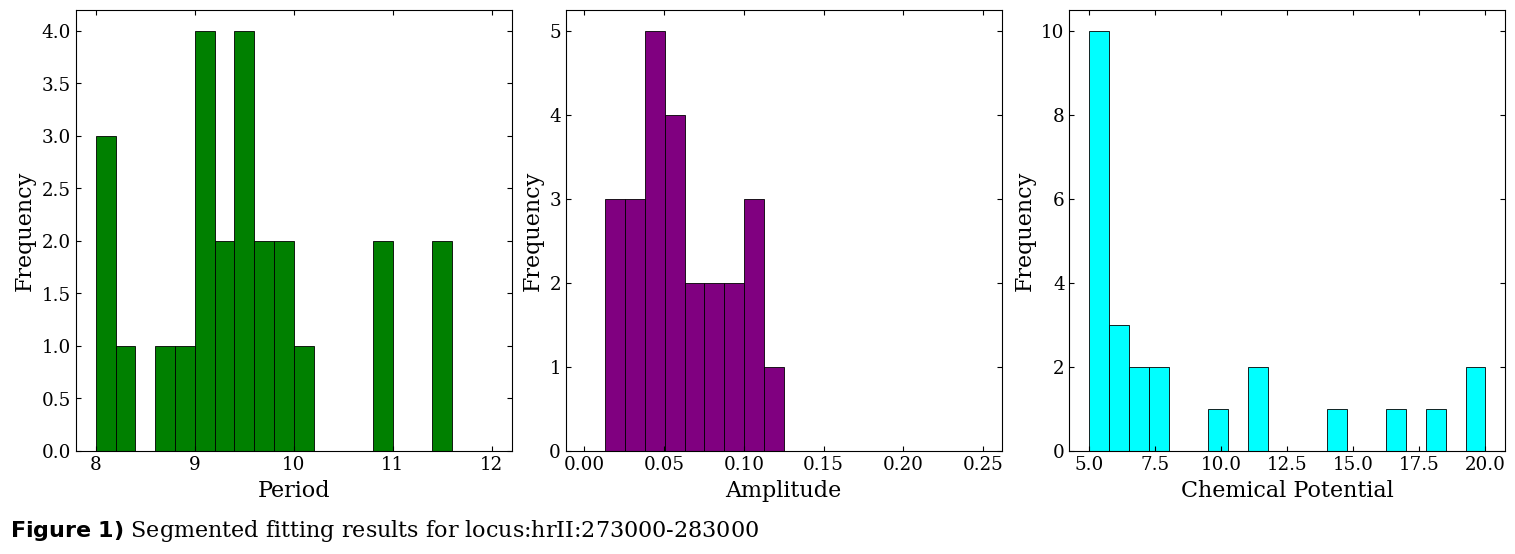

In [14]:
xs = np.linspace(0, 1, 100)
plotter = Plotter(fig_size=(15, 5))
plotter.new(ncols=3, nrows=1)
ax1, ax2, ax3 = plotter.axes
ax1.hist(var_dic['period'], bins=20, range=(8, 12),color='green', edgecolor='black', linewidth=0.6)
ax2.hist(var_dic['amplitude'], bins=20, range=(0.001, 0.249), color='purple', edgecolor='black', linewidth=0.6)
ax3.hist(var_dic['chemical_potential'], bins=20, range=(5.0, 20.0), color='cyan', edgecolor='black', linewidth=0.6)
ax1.set_xlabel("Period")
ax2.set_xlabel("Amplitude")
ax3.set_xlabel("Chemical Potential")
ax1.set_ylabel("Frequency")
ax2.set_ylabel("Frequency")
ax3.set_ylabel("Frequency")

plotter.caption(f"Segmented fitting results for locus:{chrom}:{start}-{end}")

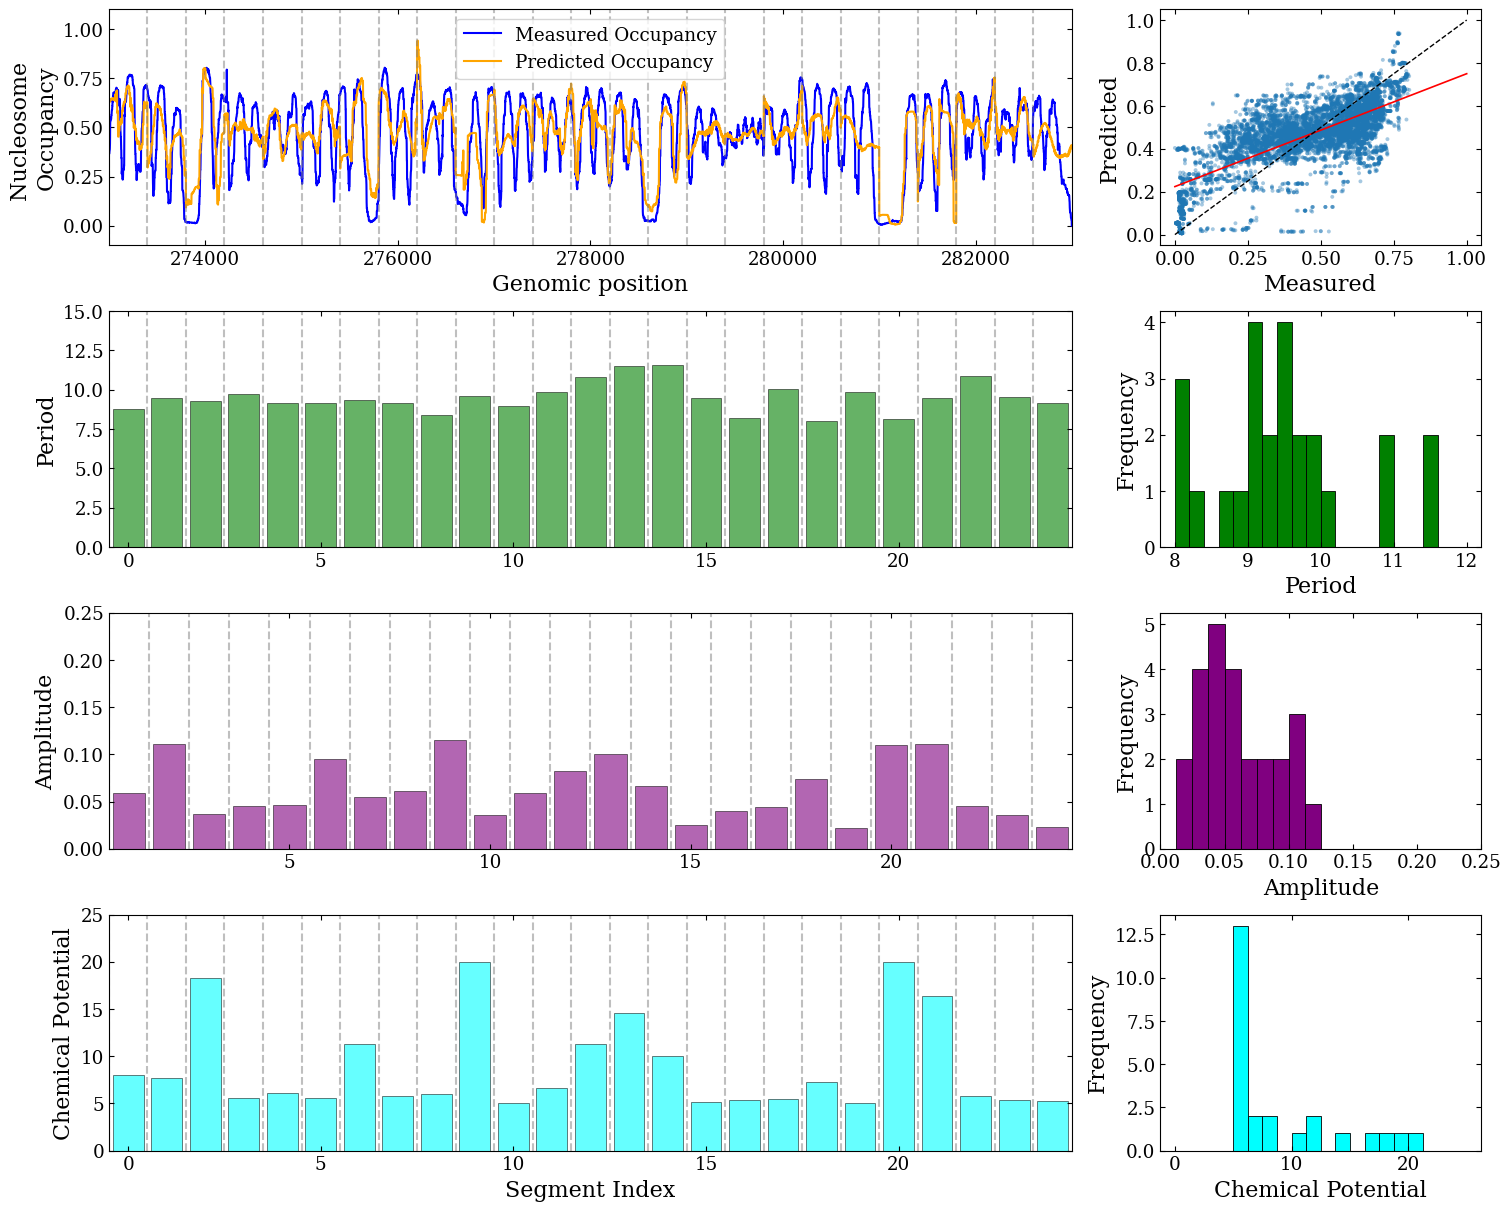

In [26]:
xs = np.linspace(0, 1, 100)

plotter = Plotter(fig_size=(15, 12))
plotter.new(ncols=2, nrows=4, width_ratios=[3, 1])
(ax1, ax1b), (ax2, ax2b), (ax3, ax3b), (ax4, ax4b) = plotter.axes
ax1.plot(x_coords, occupancy, color='blue', label='Measured Occupancy')
ax1.plot(x_coords, distribution, color='orange', label='Predicted Occupancy')
ax1.vlines(x_coords[::segment_length], ymin=-0.1, ymax=1.1, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylim(-0.1, 1.1)
ax1.set_xlim(start, end)

ax1b.scatter(m, p, s=8, alpha=0.4, edgecolor='none')
ax1b.plot(xs, s*xs + i, 'r-', lw=1.2, label=f'fit: y = {s:.2f}x + {i:.2f}')
ax1b.plot(xs, xs, 'k--', lw=1, label='y = x')
ax1b.set_xlabel("Measured")
ax1b.set_ylabel("Predicted")

ax2.bar(range(len(var_dic['period'])), var_dic['period'], edgecolor='black', linewidth=0.6, color='green', alpha=0.6, label='Period')
ax2.vlines(np.arange(0, segments)-0.5, ymin=0, ymax=15, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylim(0, 15)
ax2.set_xlim(-0.5, segments-0.5)

ax2b.hist(var_dic['period'], bins=20, range=(8, 12),color='green', edgecolor='black', linewidth=0.6)
ax2b.set_xlabel("Period")
ax2b.set_ylabel("Frequency")

ax3.bar(range(len(var_dic['amplitude'])), var_dic['amplitude'], edgecolor='black', linewidth=0.6, color='purple', alpha=0.6, label='Amplitude')
ax3.vlines(np.arange(0, segments)-0.5, ymin=0, ymax=1, color='gray', linestyle='--', alpha=0.5)
ax3.set_ylim(0, 0.25)
ax3.set_xlim(0.5, segments-0.5)

ax3b.hist(var_dic['amplitude'], bins=20, range=(0, 0.25),color='purple', edgecolor='black', linewidth=0.6)
ax3b.set_xlabel("Amplitude")
ax3b.set_ylabel("Frequency")
ax3b.set_xlim(0.0, 0.25)
ax3b.set_xticks(np.arange(0, 0.3, 0.05))

ax4.bar(range(len(var_dic['chemical_potential'])), var_dic['chemical_potential'], edgecolor='black', linewidth=0.6, color='cyan', alpha=0.6, label='Chemical Potential')
ax4.vlines(np.arange(0, segments)-0.5, ymin=0, ymax=25, color='gray', linestyle='--', alpha=0.5)
ax4.set_ylim(0, 25)
ax4.set_xlim(-0.5, segments-0.5)
ax4.set_xlabel("Segment Index")

ax4b.hist(var_dic['chemical_potential'], bins=20, range=(0, 25),color='cyan', edgecolor='black', linewidth=0.6)
ax4b.set_xlabel("Chemical Potential")
ax4b.set_ylabel("Frequency")

ax1.set_xlabel("Genomic position")
ax1.set_ylabel("Nucleosome \nOccupancy")
ax2.set_ylabel("Period")
ax3.set_ylabel("Amplitude")
ax4.set_ylabel("Chemical Potential")
ax1.legend()